# GPGN268 - Geophysical Data Analysis
## Data Story 01 - Well Logging

**Student:** Isaac Peck
**Collaborators**
Maddox Chastain helped me figure out how to get the funky double line in the hole graph, and get rid of the random diagonal line in the gamma ray graph
**Date:** February 23, 2026


Introduction:
Well logging is the process of creating a record (or log) of the geological makeup of a borehole. Many different properties are measured through this process including the density of the ground, the released gamma rays, the porosity, the resistivity, and the porosity. This data is used to analyze formations deep under the ground which is helpful for developing a detailed model of an area's geography.It is also especially useful for finding deposits of fluids such as oil, gas, and water. This makes well logging potentially very valuable. 
RHON measures density and in the data used in this project is measured in grams per cubic centimeter. A common tool used to measure this is the Compensated Neutron Tool (CNT). BPHI and TNPH measure porosity and are measured in a percentage of the soil made up of empty space. A common tool used to measure porosity is the Neutron Porotsity (NPHI) tool. UCAV measures the width of the hole at all depths as the hole is dug and is measured in inches. A coommon tool used to measure hole diameter is a caliper probe. GRMA and GRRAB measure the amount of ambient gamma rays produced by the surrounding soil and are measured in American Petroleum Institute Gamma Ray Units (gAPI). The common tool used to measure gamma rays is a scintillation detector, such as Socium Iodide crystals. RES_BD, A40B, and P16B measure the resisitivity at different depths into the surrounding rock and are measured in Ohms. A common tool used to measure resisitivity is a Laterolog in water based mud and some form of induction tool for oil based muds. Vp and Vs measure th espeed of P and S waves respectively as they move through the rock and are measured in meters per second. A common tool used to measure these are P-S loggers or sometimes Dipole Sonic Logging tools. 

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [73]:
#I aint writing this every time, it a variable now
path = r"C:\Users\isaac\OneDrive\Desktop\GPGN268\coursework-peck\ds01-well-log\data\well-log-data\A\\"

#Hole size
UCAV = pd.read_csv(path + "372-U1517A_cali-nscope.csv", skiprows=[0,1,2,3,5])
UCAV.set_index("DEPTH_LSF", inplace=True)

#Density
RHON = pd.read_csv(path + "372-U1517A_den-nscope.csv", skiprows=[0,1,2,3,5])
RHON.set_index("DEPTH_LSF", inplace=True)

#Gamma Ray
GR_RAB = pd.read_csv(path + "372-U1517A_gr-gvr.csv", skiprows=[0,1,2,3,5])
GR_RAB.set_index("DEPTH_LSF", inplace=True)

#Gamma Ray - Alternative
GRMA = pd.read_csv(path + "372-U1517A_gr-nscope.csv", skiprows=[0,1,2,3,5])
GRMA.set_index("DEPTH_LSF", inplace=True)

#Porosity
BPHI = pd.read_csv(path + "372-U1517A_por-nscope.csv", skiprows=[0,1,2,3,5], usecols={"DEPTH_LSF", "BPHI"})
BPHI.set_index("DEPTH_LSF", inplace=True)

#Porositty - Alternative
TNPH = pd.read_csv(path + "372-U1517A_por-nscope.csv", skiprows=[0,1,2,3,5], usecols={"DEPTH_LSF", "TNPH"})
TNPH.set_index("DEPTH_LSF", inplace=True)


#Resistivity
A40B = pd.read_csv(path + "372-U1517A_res-atten-nscope.csv", skiprows=[0,1,2,3,5], usecols={"DEPTH_LSF", "A40B"})
A40B.set_index("DEPTH_LSF", inplace=True)

#Resistivity 2
RES_BD = pd.read_csv(path + "372-U1517A_res-gvr.csv", skiprows=[0,1,2,3,5], usecols={"DEPTH_LSF", "RES_BD"})
RES_BD.set_index("DEPTH_LSF", inplace=True)

#Resistivity 3
P16B = pd.read_csv(path + "372-U1517A_res-phase-nscope.csv", skiprows=[0,1,2,3,5], usecols={"DEPTH_LSF", "P16B"})
P16B.set_index("DEPTH_LSF", inplace=True)

#Velocity
VCO_VSH = pd.read_csv(path + "372-U1517A_vel-sscope.csv", skiprows=[0,1,2,3,5], usecols={"DEPTH_LSF", "VCO", "VSH"})
VCO_VSH.set_index("DEPTH_LSF", inplace=True)
VCO_VSH.replace(-1000, np.nan, inplace=True)
VCO_VSH.replace(-999.25, np.nan, inplace=True)

#concatenated
Combinacionales = pd.concat([UCAV, RHON, GR_RAB, GRMA, BPHI, TNPH, A40B, RES_BD, P16B, VCO_VSH], axis=1)
Combinacionales.to_csv(r"C:\Users\isaac\OneDrive\Desktop\GPGN268\coursework-peck\ds01-well-log\Combinacionales.csv")

Text(0.5, 0.98, 'Summary of logs in Hole U1517A - IODP Expedition 372')

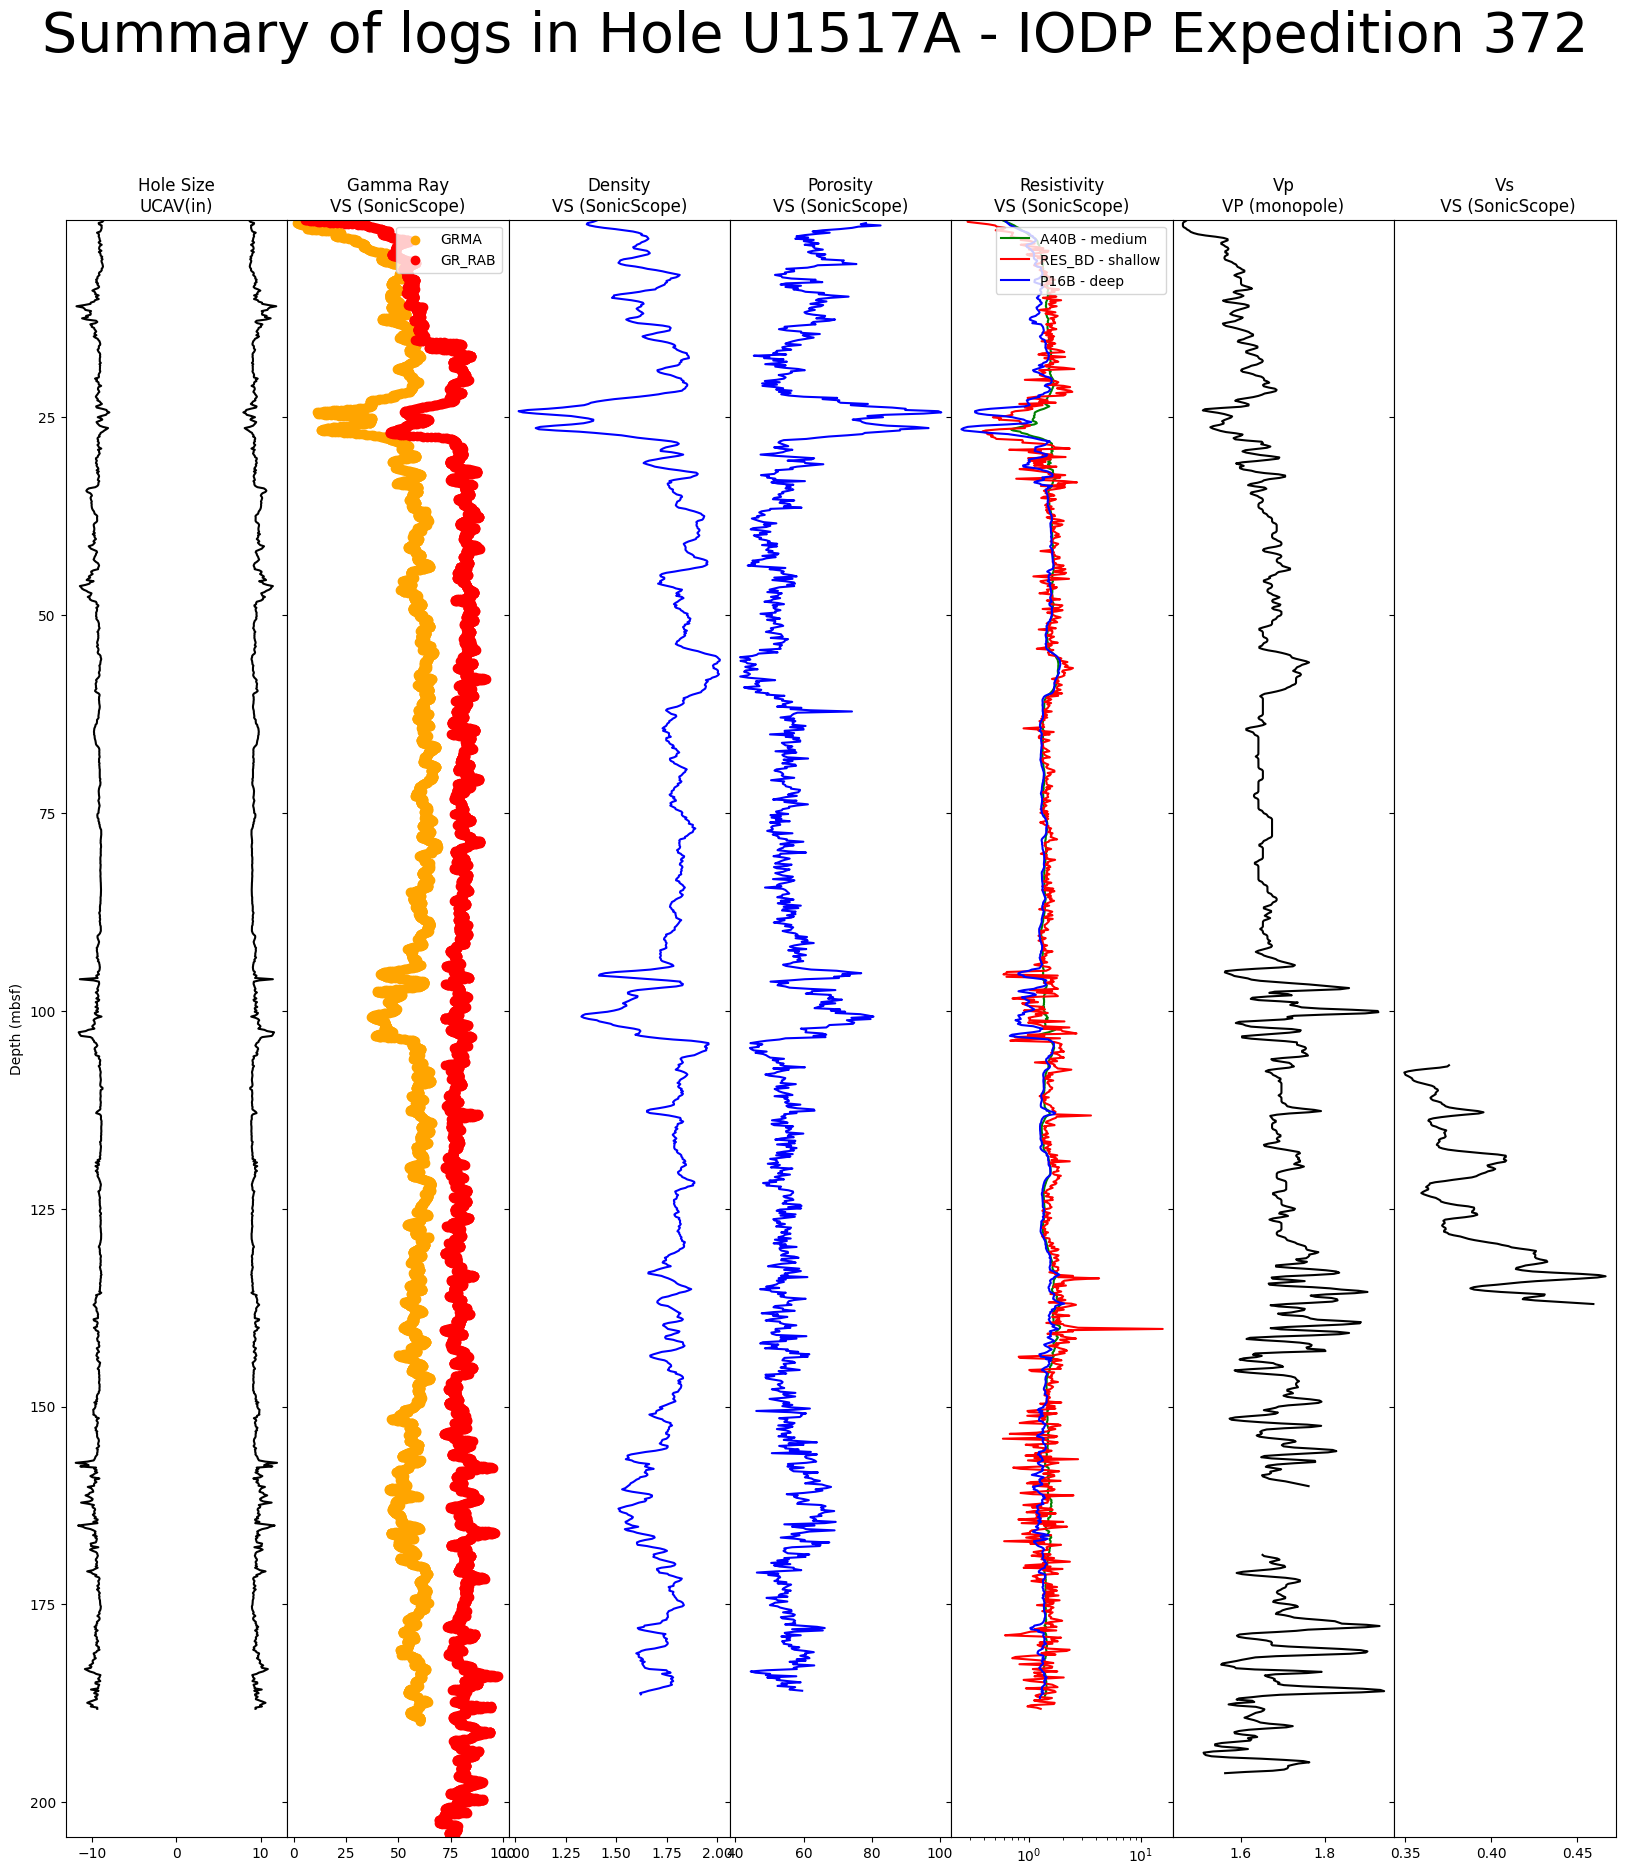

In [74]:
from matplotlib.ticker import MultipleLocator
fig, ax = plt.subplots(1,7, sharey=True, figsize=(20, 21))
fig.subplots_adjust(wspace=0)


ax[0].plot(Combinacionales["UCAV"], y, color="black")
ax[0].plot(-(Combinacionales["UCAV"]), y, color="black")
ax[0].set_title("Hole Size\nUCAV(in)")
ax[0].margins(y=0)
ax[0].set_ylabel("Depth (mbsf)")

ax[1].scatter(Combinacionales["GRMA"], y, color="orange", label="GRMA")
ax[1].scatter(Combinacionales["GR_RAB"], y, color="red", label="GR_RAB")
ax[1].set_title("Gamma Ray\nVS (SonicScope)")
ax[1].legend(loc="upper right")  

ax[2].plot(Combinacionales["RHON"], y, color="blue")
ax[2].set_title("Density\nVS (SonicScope)")

ax[3].plot(Combinacionales["BPHI"], y, color="blue")
ax[3].set_title("Porosity\nVS (SonicScope)")

ax[4].plot(Combinacionales["A40B"], y, color="green", label="A40B - medium")
ax[4].plot(Combinacionales["RES_BD"], y, color="red", label="RES_BD - shallow")
ax[4].plot(Combinacionales["P16B"], y, color="blue", label="P16B - deep")
ax[4].set_xscale('log')
ax[4].set_title("Resistivity\nVS (SonicScope)")
ax[4].legend(loc="upper right")

ax[5].plot(Combinacionales["VCO"], y, color="black")
ax[5].set_title("Vp\nVP (monopole)")

ax[6].plot(Combinacionales["VSH"], y, color="black")
ax[6].set_title("Vs\n VS (SonicScope)")

ax[0].invert_yaxis()

fig.suptitle('Summary of logs in Hole U1517A - IODP Expedition 372', fontsize=40)

At a depth of about 25 meters there is a clear spike in gamma rays, density, porosity, and resisitivity. This points to a pocket of a different material being present at this depth. Based on the changes in the data it is highly likely that this pocket is clay and the surrounding soil is some type of sand. Clay has a higher porosity, gamma radiation, and density than sand. Another similar although less pronounced pocket can be seen at 100 meters likely pointing to another quanitity of clay at this depth. 
At the shallowest areas of the bore hole gamma radiation is very low and increases to a relatively stable level over the next few meters likely due to there being no radioactive material above the probe at this point. There is a similar pattern with density and porosity possibly due to the low pressure in this region leading to minimal compacting of the soil. Resisitivity is also very low at the surface which could be caused by moisture and organic material present on the surface acting as conductors which are then increasingly absent as the bore depth increases. There is one massive jump in resistivity somewhere between 125 and 150 meters depth which may have been an equipment malfunction.  